Original Dataset:
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   
3            4              4     5.0    58      +17.181      5707797   
4            5              5     4.0    58      +18.014      5708630   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  


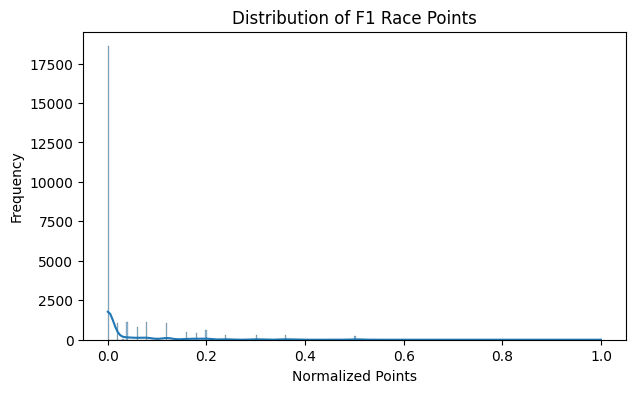

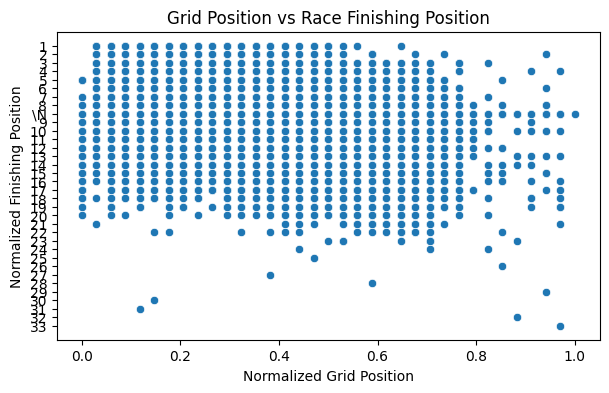

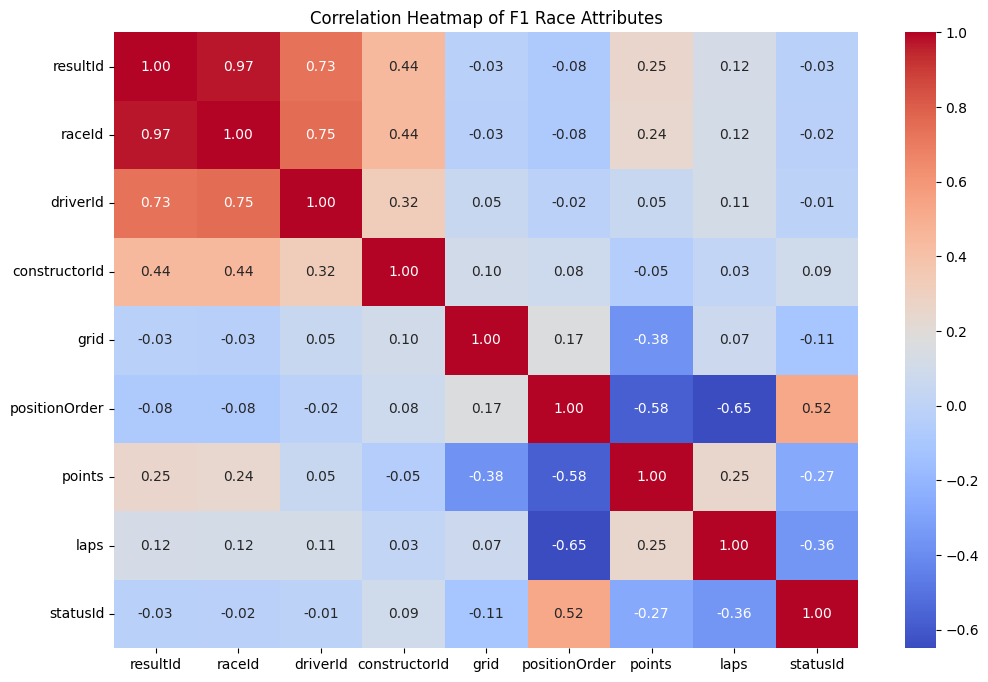


Cleaned Dataset Saved Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Load Dataset
df = pd.read_csv("results.csv")

print("Original Dataset:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Check Duplicate Records
print("\nDuplicate Rows:", df.duplicated().sum())

# Handle Missing Values
num = df.select_dtypes(include=np.number).columns

for col in num:
    df[col] = df[col].fillna(df[col].mean())

# Remove Duplicate Records
df = df.drop_duplicates()

# Clean Column Names
df.columns = df.columns.str.strip()

# Normalize Numerical Columns
scaler = MinMaxScaler()

df[num] = scaler.fit_transform(df[num])

# Check Missing Values After Cleaning
print("\nMissing Values After Cleaning:")
print(df.isnull().sum().sum())

# Display Cleaned Dataset
print("\nCleaned Dataset:")
print(df.head())

# Histogram – Points Distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["points"], kde=True)
plt.title("Distribution of F1 Race Points")
plt.xlabel("Normalized Points")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot – Grid vs Position
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="grid",
    y="position"
)
plt.title("Grid Position vs Race Finishing Position")
plt.xlabel("Normalized Grid Position")
plt.ylabel("Normalized Finishing Position")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    df[num].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of F1 Race Attributes")
plt.show()

# Save Cleaned Dataset
df.to_csv("F1_Cleaned.csv", index=False)

print("\nCleaned Dataset Saved Successfully")